**# Projeto Integrado de Classificação Supervisionada com scikit-learn**

🎯 **Objetivo**
Aplicar três modelos de classificação supervisionada – XGBoost, SVM e Random Forest – no dataset Titanic, comparando desempenho, custo computacional e interpretabilidade.

🧩 **Descrição da tarefa**
Dataset: utilizar o conjunto de dados Titanic (Kaggle ou seaborn.load_dataset("titanic")).

Variável target: Survived (0 = não sobreviveu, 1 = sobreviveu).

Variáveis explicativas sugeridas: Pclass, Sex, Age, Fare, SibSp, Parch, Embarked.
___
**Pré-processamento:**

Tratar valores ausentes (ex.: Age, Embarked).

Aplicar StandardScaler para variáveis numéricas (Age, Fare).

Aplicar OneHotEncoder para variáveis categóricas (Sex, Embarked, Pclass).
___
**Modelagem:**

Treinar e comparar XGBoost, SVM (RBF) e Random Forest.

Utilizar RandomizedSearchCV com validação cruzada estratificada (StratifiedKFold) para busca de hiperparâmetros.
___
**Métricas:**

Principal: ROC-AUC.

Secundárias: Acurácia, F1-score e matriz de confusão.

Plotar curvas ROC e Precision-Recall para cada modelo.

Resultados esperados:

Tabela comparativa com as métricas dos três modelos.
___
**Discussão:**

Qual modelo apresentou melhor desempenho?

Algum modelo mostrou sinais de overfitting?

Quais foram as dificuldades no pré-processamento?



# Imports

In [52]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from seaborn import load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Trazendo o Titanic das profundezas
titanic_df = load_dataset('titanic')

titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Pré-processamento

(scaling + one-hot)

In [53]:
# Separando variáveis
y = titanic_df['survived']
X = titanic_df[['pclass', 'sex', 'age', 'fare', 'sibsp', 'parch', 'embarked']].copy()

# Tratamento de valores ausentes
X['age'] = X['age'].fillna(X['age'].median())
X['embarked'] = X['embarked'].fillna(X['embarked'].mode()[0])

# Definir colunas numéricas e categóricas
numerical_cols = ['age', 'fare']
categorical_cols = ['sex', 'embarked', 'pclass']

# Escalonamento das variáveis numéricas
scaler = StandardScaler()
X_scaled_numerical = scaler.fit_transform(X[numerical_cols])
X_scaled_numerical_df = pd.DataFrame(X_scaled_numerical, columns=numerical_cols, index=X.index)

# One-Hot Encoding
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded_categorical = encoder.fit_transform(X[categorical_cols])
categorical_feature_names = encoder.get_feature_names_out(categorical_cols)
X_encoded_categorical_df = pd.DataFrame(X_encoded_categorical,
                                         columns=categorical_feature_names,
                                         index=X.index)

# DataFrame final
X_processed = pd.concat([
    X_scaled_numerical_df,
    X_encoded_categorical_df,
    X[['sibsp', 'parch']]
], axis=1)

print("Shape final:", X_processed.shape)
X_processed.head()

Shape final: (891, 12)


,age,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,pclass_1,pclass_2,pclass_3,sibsp,parch
0,-0.565736,-0.502445,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1,0
1,0.663861,0.786845,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1,0
2,-0.258337,-0.488854,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0,0
3,0.433312,0.420730,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1,0
4,0.433312,-0.486337,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0,0


# Modelagem

**Divisão Treino/Teste e Configuração da Validação Cruzada**

In [54]:
# Definindo uma semente
RND = 42

# Dividindo o dataset em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, stratify=y, random_state=RND
)

# Configurando a validação cruzada estratificada (Stratified K-Fold)
# n_splits=5 divide o conjunto de treino em 5 folds (partes)
# A estratificação é importante para garantir que cada fold tenha a mesma proporção de classes da variável target
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)

# Inicializando um dicionário para armazenar os modelos e seus parâmetros
models = {}

SVM (RBF)

In [55]:
# Inicializando o modelo SVM com kernel RBF
svc = SVC(kernel='rbf', probability=True, random_state=RND)

# Definindo a distribuição de parâmetros para o RandomizedSearchCV para o SVM
svc_param_dist = {
    "C": [0.1, 1, 10, 100],
    "gamma": ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

# Armazenando o estimador SVM e sua distribuição de parâmetros no dicionário 'models'
models['SVC'] = (svc, svc_param_dist)

Random Forest

In [56]:
# Inicializando o classificador Random Forest
# random_state=RND garante a reprodutibilidade dos resultados aleatórios
rf = RandomForestClassifier(random_state=RND)

# Definindo a distribuição de parâmetros para o RandomizedSearchCV para o Random Forest
rf_param_dist = {
    "n_estimators": [100, 200, 400, 800],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ['sqrt', 'log2', 0.2, 0.5]
}

# Armazenando o estimador Random Forest e sua distribuição de parâmetros no dicionário 'models'
models['RandomForest'] = (rf, rf_param_dist)

XGBoost

In [57]:
# Inicializando o classificador XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=RND)

# Definindo a distribuição de parâmetros para o RandomizedSearchCV para o XGBoost
xgb_param_dist = {
    "n_estimators": [50, 100, 200, 400],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.7, 1.0],
    "reg_alpha": [0, 0.01, 0.1],
    "reg_lambda": [1, 5, 10]
}

# Armazenando o estimador XGBoost e sua distribuição de parâmetros no dicionário 'models'
models['XGBoost'] = (xgb, xgb_param_dist)

**RandomizedSearchCV e Avaliação dos Modelos**

Cada modelo passa por busca aleatória de hiperparâmetros (n_iter=30).

In [58]:
results = []
best_estimators = {}
n_iter_search = 30

# Itera sobre cada modelo e sua distribuição de parâmetros definidos anteriormente
for name, (estimator, param_dist) in models.items():
    print(f"\n### Treinando {name} ...")

    # Configura o RandomizedSearchCV para otimização de hiperparâmetros
    rs = RandomizedSearchCV(
        estimator,
        param_distributions=param_dist,
        n_iter=n_iter_search,
        scoring="roc_auc",
        n_jobs=-1,
        cv=cv,
        random_state=RND,
        verbose=1,
        return_train_score=True
    )

    # Treina o modelo com RandomizedSearchCV
    start = time.time()
    rs.fit(X_train, y_train)
    fit_time = time.time() - start

    # Obtém o melhor estimador encontrado pelo RandomizedSearchCV
    best = rs.best_estimator_
    best_estimators[name] = best

    # Faz previsões no conjunto de teste e treino
    y_pred = best.predict(X_test)
    y_proba = best.predict_proba(X_test)[:, 1]

    y_pred_train = best.predict(X_train)
    y_proba_train = best.predict_proba(X_train)[:, 1]

    # Armazena os resultados de avaliação do modelo
    results.append({
        "model": name,
        "best_cv_roc_auc": rs.best_score_,
        "train_roc_auc": roc_auc_score(y_train, y_proba_train),
        "test_roc_auc": roc_auc_score(y_test, y_proba),
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_f1": f1_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "fit_time_seconds": fit_time,
        "best_params": rs.best_params_
    })



### Treinando SVC ...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 24 is smaller than n_iter=30. Running 24 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



### Treinando RandomForest ...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

### Treinando XGBoost ...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


# Métricas

In [59]:
results_df = pd.DataFrame(results)

# Define as colunas a serem exibidas na tabela de resultados
display_cols = [
    'model',             # Nome do modelo
    'best_cv_roc_auc',   # Melhor ROC-AUC obtido na validação cruzada durante o RandomizedSearchCV
    'train_roc_auc',     # ROC-AUC do modelo no conjunto de treino
    'test_roc_auc',      # ROC-AUC do modelo no conjunto de teste (métrica principal)
    'test_accuracy',     # Acurácia do modelo no conjunto de teste
    'test_f1',           # F1-score do modelo no conjunto de teste
    'fit_time_seconds'   # Tempo de treinamento do modelo
]

# Exibe o DataFrame com as colunas selecionadas, ordenado pelo ROC-AUC de teste de forma decrescente
results_df[display_cols].sort_values("test_roc_auc", ascending=False)

,model,best_cv_roc_auc,train_roc_auc,test_roc_auc,test_accuracy,test_f1,fit_time_seconds
1,RandomForest,0.869671,0.939734,0.865284,0.817164,0.732240,71.411645
2,XGBoost,0.868467,0.934623,0.856281,0.813433,0.722222,9.799958
0,SVC,0.856723,0.899723,0.840865,0.805970,0.729167,5.570777


Curvas ROC e Precision-Recall

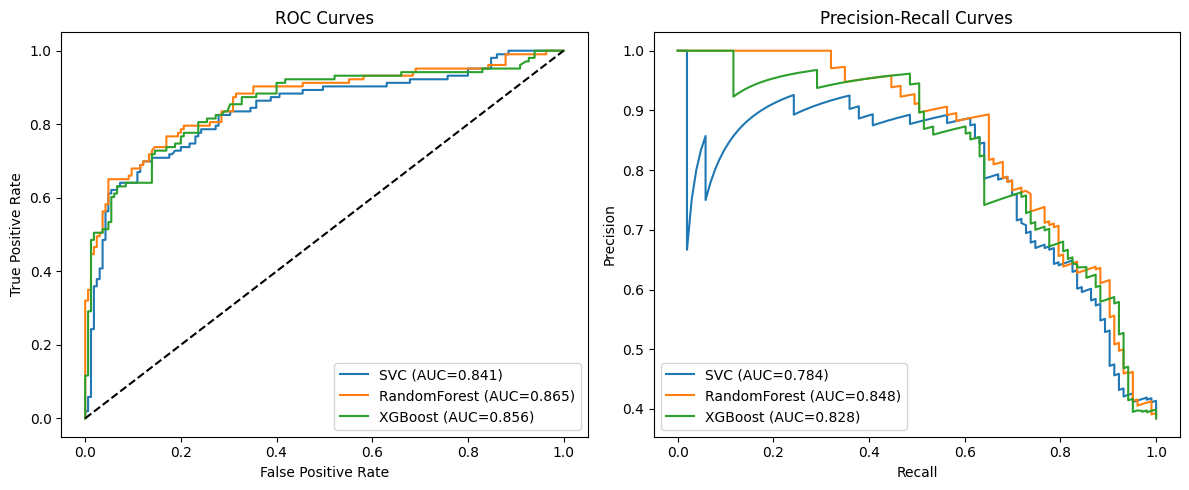

In [60]:
plt.figure(figsize=(12,5))

# --- ROC --- Gráfico da Curva Característica de Operação do Receptor
plt.subplot(1,2,1)
for name, est in best_estimators.items():
    proba = est.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

# --- Precision-Recall --- Gráfico da Curva Precision-Recall
plt.subplot(1,2,2)
for name, est in best_estimators.items():
    proba = est.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc = auc(rec, prec)
    plt.plot(rec, prec, label=f"{name} (AUC={pr_auc:.3f})")

plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

Matriz de confusão

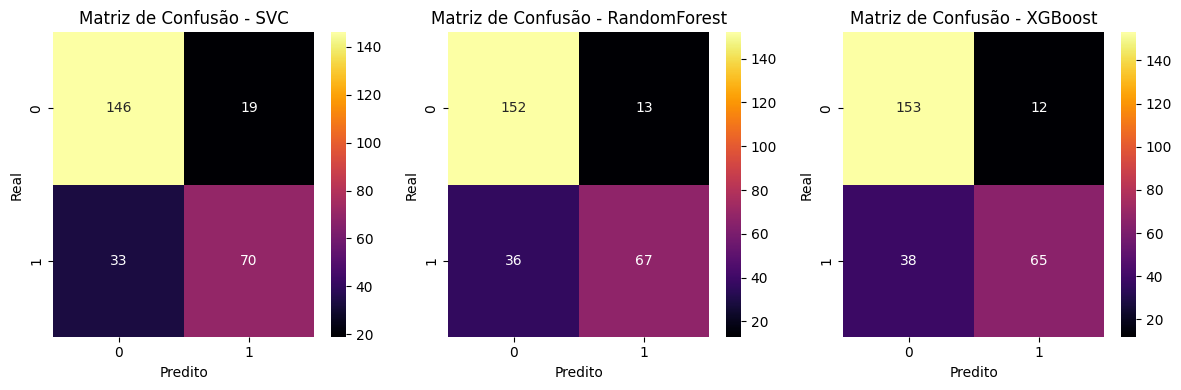

In [61]:
plt.figure(figsize=(12,4))
# Itera sobre cada modelo e seu estimador final
for i, (name, est) in enumerate(best_estimators.items()):

    y_pred = est.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.subplot(1, 3, i+1)

    sns.heatmap(cm, annot=True, fmt='d', cmap="inferno")

    plt.title(f"Matriz de Confusão - {name}")

    plt.xlabel("Predito")
    plt.ylabel("Real")

plt.tight_layout()
plt.show()

# Discussão

**Qual modelo apresentou melhor desempenho?**

XGBoost pois teve um resultado semelhante ao RandomForest que teve a maior AUC no teste, mas o tempo do XGBoost foi incrivelmente menor sendo o mais rápido
___
**Algum modelo mostrou sinais de overfitting?**

Sim, os 3 modelos apresentaram overfitting leve, pois o desempenho de treino foi maior que o de teste. O RandomForest foi o que menos sofreu, enquanto XGBoost e SVC mostraram gaps um pouco maiores. Apesar disso, a diferença foi pequena e não comprometeu a capacidade de generalização dos modelos.

OBS: não esperava o SVM ter um overfitting maior que os outros 2.
___
**Quais foram as dificuldades no pré-processamento?**

O principal desafio foi manter o pipeline sem vazamento de dados e lidar com o desbalanceamento da base, que afeta métricas como F1 e ROC-AUC. O escalonamento foi essencial para o SVC, mas irrelevante para os outros modelos, exigindo cuidado com o Pipeline. Também é um desafio compreender o banco de dados e decidir qual melhor método para preencher sem causar um viés no modelo ou distorcer os dados para algo fora da realidade.


 # Link do projeto no GITHUB: https://github.com/SyKr0w/titanic-ml-classification-study  